---
format:
  html:
    code-fold: false
execute:
  echo: true
---

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatthewAlexanderFisher/NCL-MAS3919/blob/main/content/practicals/3-training-ml-models-in-pytorch.ipynb)


# Training Machine Learning Models in Pytorch {#sec-practical-pytorch-training} 

In this practical, we explore how to train a PyTorch implemented **machine learning model**.

## Recap

In the previous practical, we introduced the basics of implementing models in PyTorch. A **machine learning model** is simply a *parametric class of functions*:
$$
\mathcal{F} = \{ f_{\boldsymbol{\theta}} \mid \boldsymbol{\theta} \in \Theta \},
$$
where:

- $\boldsymbol{\theta}$ is a **parameter vector**
- $\Theta$ is the **parameter space**
- each $f_{\boldsymbol{\theta}} : \mathcal{X} \to \mathcal{Z}$ is a function

In PyTorch, a model is a subclass of `nn.Module` (`nn` stands for *neural network*). The general pattern is:

```python
import torch
import torch.nn as nn

class Model(nn.Module):

    def __init__(self):
        super().__init__()   # initialise the parent class

        # Define parameters here
        # Example:
        self.theta = nn.Parameter(torch.randn(1))

    def forward(self, x):
        # Define the function f_theta(x) here
        return self.theta * x
```

The key components are:

* It is a **Python class**
* It **inherits** from `nn.Module`
* The `__init__` method defines the parameters (using `nn.Parameter`)
* The `forward` method defines the function $f_{\boldsymbol{\theta}}(\boldsymbol{x})$.




## Training ML models

Suppose we have a model $f_{\boldsymbol{\theta}}$ parameterised by parameters  
$\boldsymbol{\theta} \in \mathbb{R}^p$.

The model takes an input $\boldsymbol{x}$ and produces an output

$$
\boldsymbol{z} = f_{\boldsymbol{\theta}}(\boldsymbol{x}) \in \mathcal{Z}.
$$

The space $\mathcal{Z}$ depends on the problem:

- in **regression**, typically $\mathcal{Z} = \mathbb{R}$ or $\mathbb{R}^k$,
- in **classification**, $\mathcal{Z}$ often represents **scores or probabilities** associated with each class.

To train the model we require a dataset of input–output pairs

$$
D = \{(\boldsymbol{x}_i, y_i)\}_{i=1}^n,
$$

where

- $\boldsymbol{x}_i \in \mathcal{X}$ is the input
- $y_i \in \mathcal{Y}$ is the corresponding label.

### Loss functions

To measure how well the model output matches the true label, we introduce a **loss function**

$$
L : \mathcal{Z} \times \mathcal{Y} \to \mathbb{R}.
$$

For a given example $(\boldsymbol{x}, y)$, the loss is

$$
L\big(f_{\boldsymbol{\theta}}(\boldsymbol{x}), y\big),
$$

which assigns a penalty when the model output differs from the true label.

The goal of training is to choose parameters $\boldsymbol{\theta}$ that minimise the **expected risk**

$$
\mathcal{R}(f_{\boldsymbol{\theta}})
=
\mathbb{E}_{(\boldsymbol{x},y)}
\left[
L\big(f_{\boldsymbol{\theta}}(\boldsymbol{x}),y\big)
\right].
$$

However, since the true data distribution is unknown, we instead minimise the **empirical risk**

$$
\mathcal{R}_n(f_{\boldsymbol{\theta}})
=
\frac{1}{n}
\sum_{i=1}^n
L\big(f_{\boldsymbol{\theta}}(\boldsymbol{x}_i),y_i\big).
$$

Thus the training problem becomes

$$
\min_{\boldsymbol{\theta}} \mathcal{R}_n(f_{\boldsymbol{\theta}}).
$$

### Gradient-based optimisation

In genera, for most machine learning models, the function $f_{\boldsymbol{\theta}}$ is typically highly nonlinear, so this optimisation problem cannot be solved analytically.

Instead we use **gradient-based optimisation methods**, which iteratively update the parameters according to

$$
\boldsymbol{\theta}_{t+1}
=
\boldsymbol{\theta}_t
-
\eta \nabla_{\boldsymbol{\theta}}
\mathcal{R}_n(f_{\boldsymbol{\theta}_t}),
$$

where

- $\eta > 0$ is the learning rate
- $\nabla_{\boldsymbol{\theta}} \mathcal{R}_n(f_{\boldsymbol{\theta}_t})$ is the gradient of the empirical risk.

Computing this gradient requires summing over all $n$ training examples, which can be expensive for large datasets.

### Stochastic gradient descent

To reduce this cost we use **stochastic gradient descent (SGD)**.

Rather than computing the gradient over the entire dataset, we instead sample a mini-batch

$$
B_t \subset \{1,\dots,n\}.
$$

We define the **mini-batch empirical risk**

$$
\mathcal{R}_{B_t}(f_{\boldsymbol{\theta}})
=
\frac{1}{|B_t|}
\sum_{i \in B_t}
L\big(f_{\boldsymbol{\theta}}(\boldsymbol{x}_i),y_i\big).
$$

The gradient is then approximated by

$$
\nabla_{\boldsymbol{\theta}}
\mathcal{R}_{B_t}(f_{\boldsymbol{\theta}})
=
\frac{1}{|B_t|}
\sum_{i \in B_t}
\nabla_{\boldsymbol{\theta}}
L\big(f_{\boldsymbol{\theta}}(\boldsymbol{x}_i),y_i\big).
$$

The parameter update becomes

$$
\boldsymbol{\theta}_{t+1}
=
\boldsymbol{\theta}_t
-
\eta
\nabla_{\boldsymbol{\theta}}
\mathcal{R}_{B_t}(f_{\boldsymbol{\theta}_t}).
$$

This gives a noisy but computationally efficient approximation to the true gradient.

---

## Training in PyTorch

In PyTorch, this optimisation process is implemented using three main components.

### Component 1: Model

We implement $f_{\boldsymbol{\theta}}$ as a **PyTorch model**.  
From the previous practical, the general pattern is:

```python
import torch
import torch.nn as nn

class Model(nn.Module):

    def __init__(self):
        super().__init__()   # initialise the parent class

        # Define parameters here
        # Example parameter:
        self.theta = nn.Parameter(torch.randn(1))

    def forward(self, x):
        # Define the function f_theta(x)
        return self.theta * x
```

The key points are:

* Models inherit from `nn.Module`
* Learnable parameters are defined in `__init__`
* The function $f_{\boldsymbol{\theta}}$ is implemented in the `forward` method

PyTorch automatically tracks the parameters $\boldsymbol{\theta}$ defined in the model so that gradients can be computed during training.

### Component 2: Loss Function

We implement the loss function $L(z, y)$ as a PyTorch function.

There are two options.

**Option 1: Implement the loss manually**

For simple problems we can write the loss function directly:

```python
def loss(z, y):
    return ((z - y)**2).mean()
```

**Option 2: Use a built-in PyTorch loss**

PyTorch provides many standard loss functions. For example:

```python
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()
```

This implements the cross-entropy loss, which is commonly used for classification problems.

A full list of available loss functions can be found in the [PyTorch documentation](https://docs.pytorch.org/docs/stable/nn.html#loss-functions).

### Component 3: Choosing the Optimiser

We must choose an optimisation algorithm to minimise the empirical risk.

PyTorch provides several optimisers. Two common examples are:

```python
import torch.optim as optim

optim.SGD
optim.Adam
```

A good default choice in many situations is [Adam](https://arxiv.org/abs/1412.6980):

```python
optimiser = optim.Adam(model.parameters(), lr=1e-3)
```

The optimiser automatically updates the model parameters $\boldsymbol{\theta}$ using the gradients computed during training.

## The Training Loop

Once the model, loss function, and optimiser are defined, we train the model using a training loop.

Each iteration of the loop performs the following steps:

1. Sample a mini-batch of data.
2. Compute model outputs $f_{\boldsymbol{\theta}}(\boldsymbol{x})$.
3. Compute the loss.
4. Compute gradients using backpropagation.
5. Update the parameters using the optimiser.

In PyTorch this typically looks like:

```python
for x, y in dataloader:

    # 1. Reset gradients
    optimiser.zero_grad()

    # 2. Compute model outputs
    z = model(x)

    # 3. Compute loss
    loss = loss_fn(z, y)

    # 4. Backpropagation
    loss.backward()

    # 5. Update parameters
    optimiser.step()
```

## Example: MNIST dataset

The **MNIST dataset** is a standard benchmark dataset used for training and evaluating machine learning models for image classification.

It consists of grayscale images of handwritten digits. Each image contains a single digit from the set  
$\{0,1,2,3,4,5,6,7,8,9\}$.

The dataset has the following structure:

- **60,000 training images**
- **10,000 test images**
- Each image is **$28 \times 28$ pixels**
- Each pixel contains an intensity value between **0 and 255**

After applying the transformation `transforms.ToTensor()`, each image is represented as a tensor with shape

$$
(1, 28, 28),
$$

where

- the first dimension corresponds to the **number of channels** (MNIST is grayscale so there is one channel),
- the remaining dimensions correspond to the **height and width** of the image.

Thus each input can be written as a tensor

$$
\boldsymbol{x} \in \mathbb{R}^{1 \times 28 \times 28}.
$$

The corresponding label

$$
y \in \{0,\dots,9\}
$$

indicates which digit appears in the image.

When we load the dataset using a `DataLoader` with batch size $64$, the model receives data in batches with shape

$$
(64, 1, 28, 28).
$$

This corresponds to

- 64 images per batch
- 1 channel
- height $28$
- width $28$

Below we visualise some examples from the dataset.


### Loading the data

We first load the data and plot some items:

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

The data looks like:

In [17]:
train_dataset.data[0].shape

torch.Size([28, 28])

Plotting the MNIST data:

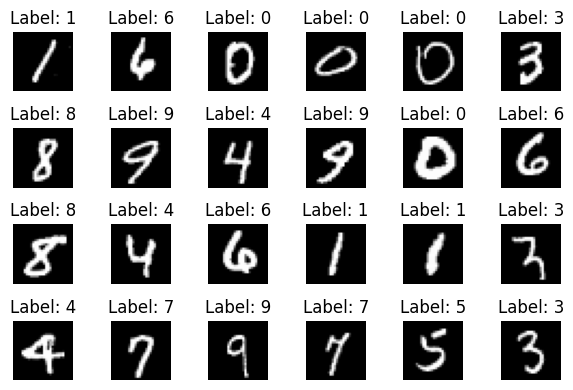

In [11]:
import matplotlib.pyplot as plt

# Get one batch of images
images, labels = next(iter(train_loader))

# Number of images to display
n = 6 * 4

fig, axes = plt.subplots(4, 6, figsize=(6, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Component 1: Defining Models

We consider three different models:

#### Logistic Regression

In [21]:
# This is just a linear map from the 28x28 image to 10 logits.
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(28 * 28, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1) # flatten to shape (batch_size, 784)
        return self.linear(x)


#### Feedforward Neural Network

In [22]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

#### Convolutional Neural Network

In [23]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),  # 28 -> 26
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                               # 26 -> 13

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3), # 13 -> 11
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)                                # 11 -> 5
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


### Component 2: Loss Function

For the MNIST dataset we wish to classify whether a given image is a digit from $\{0,1,\ldots,9\}$.

The loss function arises from a categorical probability model. Given an input $\boldsymbol{x} \in \mathcal{X}$, the model outputs a vector

$$
\boldsymbol{z} = f_{\boldsymbol{\theta}}(\boldsymbol{x}) \in \mathbb{R}^{10}.
$$

We interpret $\boldsymbol{z}$ as a vector of **logits**. These logits are converted into class probabilities using the **softmax** function:

$$
p_{\boldsymbol{\theta}}(y = k \mid \boldsymbol{x})
=
\frac{\exp(z_k)}{\sum_{j=0}^9 \exp(z_j)},
\qquad k \in \{0,\dots,9\}.
$$

Thus, for each input $\boldsymbol{x}$, the model defines a categorical distribution on $\{0,\dots,9\}$.

For a single observation $(\boldsymbol{x}_i, y_i)$, the likelihood is therefore

$$
p_{\boldsymbol{\theta}}(y_i \mid \boldsymbol{x}_i).
$$

Assuming the observations are conditionally independent given the inputs, the likelihood of the full dataset

$$
D = \{(\boldsymbol{x}_i, y_i)\}_{i=1}^n
$$

is

$$
\mathcal{L}(\boldsymbol{\theta}; D)
=
\prod_{i=1}^n p_{\boldsymbol{\theta}}(y_i \mid \boldsymbol{x}_i).
$$

Taking logarithms gives the log-likelihood

$$
\log \mathcal{L}(\boldsymbol{\theta}; D)
=
\sum_{i=1}^n \log p_{\boldsymbol{\theta}}(y_i \mid \boldsymbol{x}_i).
$$

In maximum likelihood estimation, we choose $\boldsymbol{\theta}$ to maximise this quantity. Equivalently, we minimise the **negative log-likelihood**

$$
-\log \mathcal{L}(\boldsymbol{\theta}; D)
=
-\sum_{i=1}^n \log p_{\boldsymbol{\theta}}(y_i \mid \boldsymbol{x}_i).
$$

Dividing by $n$ gives the corresponding empirical objective

$$
\mathcal{R}_n(f_{\boldsymbol{\theta}})
=
-\frac{1}{n}\sum_{i=1}^n \log p_{\boldsymbol{\theta}}(y_i \mid \boldsymbol{x}_i).
$$

So in this setting the loss function for a single observation is

$$
L\big(f_{\boldsymbol{\theta}}(\boldsymbol{x}), y\big)
=
-\log p_{\boldsymbol{\theta}}(y \mid \boldsymbol{x}).
$$

Substituting the softmax expression gives

$$
L(\boldsymbol{z}, y)
=
-\log \left(
\frac{\exp(z_y)}{\sum_{j=0}^9 \exp(z_j)}
\right).
$$

Using logarithm rules, this can be written as

$$
L(\boldsymbol{z}, y)
=
-z_y + \log\left(\sum_{j=0}^9 \exp(z_j)\right).
$$

This is exactly the **cross-entropy loss** used in multiclass classification.

Therefore, minimising the empirical risk

$$
\mathcal{R}_n(f_{\boldsymbol{\theta}})
=
\frac{1}{n}\sum_{i=1}^n L\big(f_{\boldsymbol{\theta}}(\boldsymbol{x}_i), y_i\big)
$$

is equivalent to maximising the log-likelihood under the categorical model.

### Component 3: The optimiser

We will use the Adam optimiser.

```python
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
```


### The Training Loop

In [26]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def train_one_epoch(model, dataloader, optimiser, loss_fn, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        optimiser.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimiser.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_examples += x.size(0)

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_examples += x.size(0)

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return avg_loss, accuracy


def fit(model, train_loader, test_loader, device, epochs=5, lr=1e-3):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimiser, loss_fn, device
        )
        test_loss, test_acc = evaluate(
            model, test_loader, loss_fn, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch:2d} | "
            f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
            f"test loss: {test_loss:.4f} | test acc: {test_acc:.4f}"
        )

    return model, history


### Training the models

In [ ]:
print("\nTraining logistic regression model")
logreg_model = LogisticRegressionModel()
logreg_model, logreg_history = fit(
    logreg_model, train_loader, test_loader, device=device, epochs=5, lr=1e-3
)

print("\nTraining MLP")
ffn_model = FFN()
ffn_model, ffn_history = fit(
    ffn_model, train_loader, test_loader, device=device, epochs=5, lr=1e-3
)

print("\nTraining CNN") # this can take a bit longer, especially on CPU
cnn_model = CNN()
cnn_model, cnn_history = fit(
    cnn_model, train_loader, test_loader, device=device, epochs=5, lr=1e-3
)

models = {
    "LogReg": logreg_model,
    "MLP": ffn_model,
    "CNN": cnn_model,
}

histories = {
    "LogReg": logreg_history,
    "MLP": ffn_history,
    "CNN": cnn_history,
}


Training logistic regression model
Epoch  1 | train loss: 0.5466 | train acc: 0.8669 | test loss: 0.3347 | test acc: 0.9091
Epoch  2 | train loss: 0.3236 | train acc: 0.9104 | test loss: 0.2923 | test acc: 0.9175
Epoch  3 | train loss: 0.2953 | train acc: 0.9176 | test loss: 0.2822 | test acc: 0.9213
Epoch  4 | train loss: 0.2820 | train acc: 0.9213 | test loss: 0.2765 | test acc: 0.9227
Epoch  5 | train loss: 0.2737 | train acc: 0.9234 | test loss: 0.2684 | test acc: 0.9245

Training MLP
Epoch  1 | train loss: 0.3450 | train acc: 0.8993 | test loss: 0.1661 | test acc: 0.9510
Epoch  2 | train loss: 0.1459 | train acc: 0.9568 | test loss: 0.1300 | test acc: 0.9594
Epoch  3 | train loss: 0.1001 | train acc: 0.9699 | test loss: 0.0991 | test acc: 0.9687
Epoch  4 | train loss: 0.0746 | train acc: 0.9766 | test loss: 0.0926 | test acc: 0.9706
Epoch  5 | train loss: 0.0588 | train acc: 0.9816 | test loss: 0.0755 | test acc: 0.9764

Training CNN
Epoch  1 | train loss: 0.1774 | train acc: 0.9

### Plotting output

Helper functions for plotting:

In [27]:
def plot_training_history(histories):
    """
    histories: dict of the form
        {
            "Logistic Regression": history_dict,
            "MLP": history_dict,
            "CNN": history_dict,
        }
    """
    epochs = range(1, len(next(iter(histories.values()))["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    for name, history in histories.items():
        plt.plot(epochs, history["train_loss"], label=f"{name} train")
        plt.plot(epochs, history["test_loss"], linestyle="--", label=f"{name} test")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and test loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    for name, history in histories.items():
        plt.plot(epochs, history["train_acc"], label=f"{name} train")
        plt.plot(epochs, history["test_acc"], linestyle="--", label=f"{name} test")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and test accuracy")
    plt.legend()
    plt.show()


@torch.no_grad()
def show_model_predictions(models, dataloader, device, num_images=8):
    """
    models: dict of the form
        {
            "Logistic Regression": trained_model,
            "MLP": trained_model,
            "CNN": trained_model,
        }
    """
    images, labels = next(iter(dataloader))
    images = images[:num_images].to(device)
    labels = labels[:num_images].to(device)

    predictions = {}
    for name, model in models.items():
        model.eval()
        logits = model(images)
        preds = logits.argmax(dim=1)
        predictions[name] = preds.cpu()

    images = images.cpu()
    labels = labels.cpu()

    n_models = len(models)
    fig, axes = plt.subplots(
        nrows=n_models + 1,
        ncols=num_images,
        figsize=(1.8 * num_images, 2.2 * (n_models + 1))
    )

    # If num_images == 1 or shape oddities arise, force 2D indexing
    if n_models + 1 == 1:
        axes = axes[None, :]

    # First row: true labels
    for j in range(num_images):
        axes[0, j].imshow(images[j].squeeze(), cmap="gray")
        axes[0, j].set_title(f"True: {labels[j].item()}")
        axes[0, j].axis("off")

    # Remaining rows: model predictions
    for i, (name, preds) in enumerate(predictions.items(), start=1):
        for j in range(num_images):
            axes[i, j].imshow(images[j].squeeze(), cmap="gray")
            pred = preds[j].item()
            true = labels[j].item()
            tick = "✓" if pred == true else "✗"
            axes[i, j].set_title(f"{name}\nPred: {pred} {tick}", fontsize=10)
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def show_wrong_predictions(models, dataloader, device, max_images=8):
    """
    Shows misclassified examples for each model separately.
    """
    for name, model in models.items():
        model.eval()
        wrong_images = []
        wrong_true = []
        wrong_pred = []

        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1)

            mask = preds != y
            if mask.any():
                wrong_images.append(x[mask].cpu())
                wrong_true.append(y[mask].cpu())
                wrong_pred.append(preds[mask].cpu())

            total_wrong = sum(t.size(0) for t in wrong_true)
            if total_wrong >= max_images:
                break

        if len(wrong_images) == 0:
            print(f"{name}: no misclassified images found.")
            continue

        images = torch.cat(wrong_images, dim=0)[:max_images]
        true_labels = torch.cat(wrong_true, dim=0)[:max_images]
        pred_labels = torch.cat(wrong_pred, dim=0)[:max_images]

        fig, axes = plt.subplots(1, max_images, figsize=(1.8 * max_images, 2.5))
        if max_images == 1:
            axes = [axes]

        for j in range(len(images)):
            axes[j].imshow(images[j].squeeze(), cmap="gray")
            axes[j].set_title(f"T: {true_labels[j].item()}\nP: {pred_labels[j].item()}")
            axes[j].axis("off")

        plt.suptitle(f"{name}: misclassified examples")
        plt.tight_layout()
        plt.show()

In [ ]:
plot_training_history(histories)

In [ ]:
show_model_predictions(models, test_loader, device=device, num_images=8)

In [ ]:
show_wrong_predictions(models, test_loader, device=device, max_images=8)